## 1.Load Task in Benchmark Quickly

Tutorial one is to load a task/env conveniently by simply giving task name and desired target embodiment (default is Franka).

In [1]:
import os
os.environ['DISPLAY']=":1"
# os.environ["MUJOCO_GL"] = "egl"
# os.environ["CUDA_VISIBLE_DEVICES"] = '0'
# os.environ["GPUS"] = '0'
# os.environ["PYOPENGL_PLATFORM"] = "egl"

# os.environ["LD_PRELOAD"] = "/lib/x86_64-linux-gnu/libstdc++.so.6"
# os.environ["LD_LIBRARY_PATH"] = "/lib/x86_64-linux-gnu:" + os.environ.get("LD_LIBRARY_PATH", "")
# print(os.environ["LD_LIBRARY_PATH"])
import json
from PIL import Image
from dm_control import viewer
from VLABench.envs import load_env
from VLABench.robots import *
from VLABench.tasks import *
from VLABench.configs import name2config
from VLABench.utils.utils import find_key_by_value

/usr/local/lib/python3.10/dist-packages/dash/_jupyter.py:29: DeprecationWarning: The `ipykernel.comm.Comm` class has been deprecated. Please use the `comm` module instead.For creating comms, use the function `from comm import create_comm`.
  _dash_comm = Comm(target_name="dash")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Set the embodiment and task 

In [2]:
task = "select_fruit"
robot = "franka"

If run this tutorial on server instead of PC, run in headless mode.

In [3]:
import os
os.environ["MUJOCO_GL"] = "egl"

###  1.1Load task and build environment

Each time you load the single env, each instance varies in a large range.

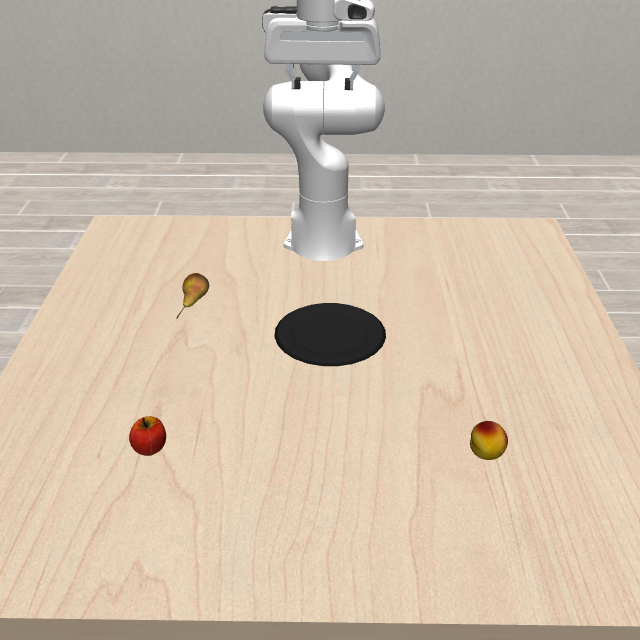

In [4]:
env = load_env(task, robot=robot, time_limit=1000)
env.reset()

image = env.render(camera_id=2, width=640, height=640)
Image.fromarray(image)

In [ ]:
obs = env.get_observation()
print(obs.keys())

AttributeError: 'VLABenchEnv' object has no attribute 'get_observation'

In [6]:
obs['extrinsic'][0]

array([[ 7.32615478e-01,  1.33813875e-01, -6.67359280e-01,
         7.75000000e-01],
       [ 6.80642756e-01, -1.44031674e-01,  7.18317698e-01,
        -8.56000000e-01],
       [-5.55111512e-17, -9.80483923e-01, -1.96599278e-01,
         1.20900000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

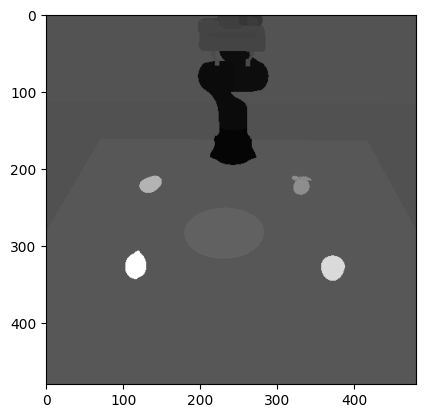

In [23]:
import matplotlib.pyplot as plt

rgb_img = obs['rgb'][2]
rgb_img = Image.fromarray(rgb_img)
depth_img = obs['depth'][2]
depth_img = Image.fromarray(depth_img)
seg_img = obs['segmentation'][2]

plt.imshow(seg_img[:, :, 0], cmap='gray')

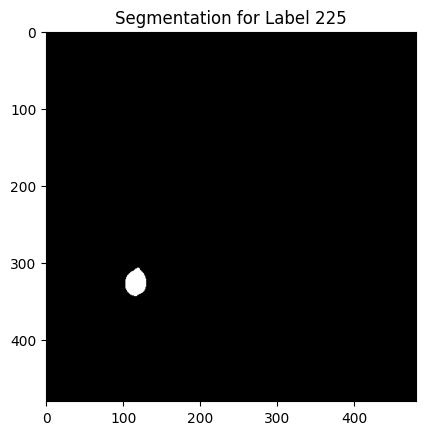

In [24]:
segmentation_result = seg_img  # 替换为你的实际分割结果
box = [90,300,140,340]
mask = np.zeros_like(segmentation_result)

segmentation_box = segmentation_result[box[1]:box[3], box[0]:box[2], :]
unique_labels,counts = np.unique(segmentation_box, return_counts=True)
valid_labels = [(label, count) for label, count in zip(unique_labels, counts) if label > 80]
most_frequent_label, max_count = max(valid_labels, key=lambda x: x[1])
unique_labels
# for label in unique_labels:
#     if label < 80:
#         continue
#     if label == 0:  # 这里假设类别值 0 是背景，如果不需要背景可以跳过
#         continue
    
#     # 提取属于当前物体的区域（mask），其像素值等于当前类别标签
#     mask = (segmentation_result == label).astype(np.uint8)  # mask 是一个二值图像

mask = (segmentation_result == most_frequent_label).astype(np.uint8)  # mask 是一个二值图像

    # 显示分割结果
plt.imshow(mask[:, :, 0], cmap='gray')  # 用灰度显示当前物体的遮罩
plt.title(f"Segmentation for Label {most_frequent_label}")
plt.show()

In [2]:
import numpy as np

def depth_to_pointcloud(depth_img, mask, intrinsic, extrinsic):
    """
    Convert depth image and mask into a 3D point cloud in world coordinates.

    Args:
        depth_img (np.ndarray): Depth image, shape (H, W).
        mask (np.ndarray): Binary mask, shape (H, W), True for points to include.
        intrinsic (np.ndarray): Camera intrinsic matrix, shape (3, 3).
        extrinsic (np.ndarray): Camera extrinsic matrix, shape (4, 4).

    Returns:
        np.ndarray: Point cloud in world coordinates, shape (N, 3), where N is the number of valid points.
    """
    # Step 1: Get intrinsic parameters
    fx, fy = intrinsic[0, 0], intrinsic[1, 1]  # Focal lengths
    cx, cy = intrinsic[0, 2], intrinsic[1, 2]  # Principal points

    # Step 2: Get pixel coordinates from mask
    mask_indices = np.where(mask)  # Get indices of the mask (y, x)
    v_coords = mask_indices[0]  # y-coordinates (rows)
    u_coords = mask_indices[1]  # x-coordinates (columns)

    # Step 3: Get corresponding depth values
    z_values = depth_img[v_coords, u_coords]  # Depth values for the selected points

    # Step 4: Convert to camera coordinates
    x_cam = (u_coords - cx) * z_values / fx
    y_cam = (v_coords - cy) * z_values / fy
    z_cam = z_values

    # Combine camera coordinates into an (N, 3) matrix
    points_cam = np.stack((x_cam, y_cam, z_cam), axis=-1)  # Shape (N, 3)

    # Step 5: Transform points from camera coordinates to world coordinates
    # Add a column of ones to apply the 4x4 matrix transformation
    points_cam_homogeneous = np.hstack((points_cam, np.ones((points_cam.shape[0], 1))))  # Shape (N, 4)

    # Apply the extrinsic matrix (T) to get world coordinates
    points_world_homogeneous = extrinsic @ points_cam_homogeneous.T  # Shape (4, N)
    points_world = points_world_homogeneous[:3, :].T  # Convert back to (N, 3)

    return points_world

def matrix_to_quaternion(matrix):
    """
    Convert a 3x3 rotation matrix to a quaternion (w, x, y, z).
    
    Args:
        matrix (np.ndarray): A 3x3 rotation matrix.
    
    Returns:
        np.ndarray: A 1D array representing quaternion [w, x, y, z].
    """
    # Ensure the input is a valid rotation matrix
    assert matrix.shape == (3, 3), "Matrix must be 3x3"

    # Compute the trace of the matrix
    trace = np.trace(matrix)

    # Allocate the quaternion array
    quaternion = np.zeros(4)

    if trace > 0:  # Case 1: Trace is positive
        s = np.sqrt(trace + 1.0) * 2  # s = 4 * w
        quaternion[0] = 0.25 * s  # w
        quaternion[1] = (matrix[2, 1] - matrix[1, 2]) / s  # x
        quaternion[2] = (matrix[0, 2] - matrix[2, 0]) / s  # y
        quaternion[3] = (matrix[1, 0] - matrix[0, 1]) / s  # z
    elif (matrix[0, 0] > matrix[1, 1]) and (matrix[0, 0] > matrix[2, 2]):  # Case 2: Column 0 has largest diagonal
        s = np.sqrt(1.0 + matrix[0, 0] - matrix[1, 1] - matrix[2, 2]) * 2  # s = 4 * x
        quaternion[0] = (matrix[2, 1] - matrix[1, 2]) / s  # w
        quaternion[1] = 0.25 * s  # x
        quaternion[2] = (matrix[0, 1] + matrix[1, 0]) / s  # y
        quaternion[3] = (matrix[0, 2] + matrix[2, 0]) / s  # z
    elif matrix[1, 1] > matrix[2, 2]:  # Case 3: Column 1 has largest diagonal
        s = np.sqrt(1.0 + matrix[1, 1] - matrix[0, 0] - matrix[2, 2]) * 2  # s = 4 * y
        quaternion[0] = (matrix[0, 2] - matrix[2, 0]) / s  # w
        quaternion[1] = (matrix[0, 1] + matrix[1, 0]) / s  # x
        quaternion[2] = 0.25 * s  # y
        quaternion[3] = (matrix[1, 2] + matrix[2, 1]) / s  # z
    else:  # Case 4: Column 2 has largest diagonal
        s = np.sqrt(1.0 + matrix[2, 2] - matrix[0, 0] - matrix[1, 1]) * 2  # s = 4 * z
        quaternion[0] = (matrix[1, 0] - matrix[0, 1]) / s  # w
        quaternion[1] = (matrix[0, 2] + matrix[2, 0]) / s  # x
        quaternion[2] = (matrix[1, 2] + matrix[2, 1]) / s  # y
        quaternion[3] = 0.25 * s  # z

    return quaternion

# points = depth_to_pointcloud(obs['depth'][2], mask[:, :, 0], obs['instrinsic'][2], obs['extrinsic'][2])

In [ ]:
import open3d as o3d
o3d_cloud = o3d.geometry.PointCloud()
o3d_cloud.points = o3d.utility.Vector3dVector(points)
file_path = "point_cloud.ply"
o3d.io.write_point_cloud(file_path, o3d_cloud)
o3d.visualization.draw_geometries([o3d_cloud])

In [31]:
import os
os.environ['DISPLAY']=":1"
import json
from PIL import Image
from functools import partial
import moviepy as mpy
from dm_control import viewer
from VLABench.envs import load_env
from VLABench.robots import *
from VLABench.tasks import *
from VLABench.utils.skill_lib import SkillLib
import requests
import numpy as np

# from utility import depth_to_pointcloud, matrix_to_quaternion

os.environ["MUJOCO_GL"] = "egl"

class VLABenchEnv():
    def __init__(self):
        
        self.env = load_env("select_fruit", robot="franka", time_limit=1000)
        self.env.reset()
        self.save_image()
        self.action_count = 0


    def save_image(self):
        image = self.env.render(camera_id=2, width=640, height=640)
        image = Image.fromarray(image)
        image.save("/workspace/robotics/home_wzr/demo/img/image.png")
        
    def send_grasp_request(self, points):
        
        url = 'http://localhost:8006/grasp'
        
        payload = {
            "points": points.tolist(),
            "colors": []
        }
        
        response = requests.post(url, json=payload).json()
        
        grasp_pose = response['grasp_pose']
        
        return grasp_pose
        
        
    def get_grasp_pose(self, box):
        obs = self.env.get_observation()
        depth_img = obs['depth'][2]
        seg_img = obs['segmentation'][2]
        segmentation_box = seg_img[box[1]:box[3], box[0]:box[2], :]
        unique_labels,counts = np.unique(segmentation_box, return_counts=True)
        valid_labels = [(label, count) for label, count in zip(unique_labels, counts) if label > 80]
        most_frequent_label, max_count = max(valid_labels, key=lambda x: x[1])

        mask = (seg_img == most_frequent_label).astype(np.uint8) 
        
        points = depth_to_pointcloud(depth_img, mask[:, :, 0], obs['instrinsic'][2], obs['extrinsic'][2])
        
        grasp_pose = self.send_grasp_request(points)
        
        rotation_matrix = np.array(grasp_pose[4:13]).reshape(3, 3)
        target_pos = np.array(grasp_pose[13:16]) 
        
        target_quat = matrix_to_quaternion(rotation_matrix)
        
        return target_pos, target_quat
        
        
    
    def execute_action(self, action, obj, box):
        
        print("start executing action")
        skill_seq = []
        try:
            if action == "pick":
                print("start pick")
                # target_pos, target_quat = self.get_grasp_pose(box)
                skill = partial(SkillLib.pick, target_entity_name = obj)
                # skill_seq.append(partial(SkillLib.pick, target_entity_name=obj))
                skill_seq.append(skill)
                print("start lift")
                skill_seq.append(partial(SkillLib.lift, lift_height=0.15))
            elif action == "place":
                print("start place")
                skill_seq.append(partial(SkillLib.place, target_container_name=obj))
        except Exception as e:
            print(f"Error executing action: {e}")
            raise
            
        key_frames = []
        for skill in skill_seq:
            print("executing skill: ",skill)
            # obs, waypoint, stage_success, task_success = skill(self.env)
            # key_frames.extend([o['rgb'][2] for o in obs])
            try:
                obs, waypoint, stage_success, task_success = skill(self.env)
                key_frames.extend([o['rgb'][2] for o in obs])
                print("Skill executed successfully.")
            except Exception as e:
                print(f"Error executing skill: {e}")
                raise
            
        print("action executed")
        # self.save_image()
        img = Image.fromarray(key_frames[-1])
        img.save(f"/workspace/robotics/home_wzr/demo/img/action_{str(self.action_count)}.png")
        img.save("/workspace/robotics/home_wzr/demo/img/image.png")
        video = mpy.ImageSequenceClip(key_frames, fps=10)
        video.write_videofile(f"/workspace/robotics/home_wzr/demo/img/action_{str(self.action_count)}.mp4", codec="libx264")
        self.action_count += 1
        success = task_success
        
        return success    
    
    def get_entities(self):
        return self.env.task.entities

    

In [33]:
env = VLABenchEnv()
entity = list(env.get_entities().keys())
print(entity)

['table', 'plate_seen', 'banana', 'mango', 'pear']


In [34]:
obs = env.env.get_observation()

In [28]:
env.get_grasp_pose([90,300,140,340])

(array([0.24519974, 0.28744814, 0.80695862]),
 array([ 0.85418936, -0.13918324, -0.40702842, -0.29208979]))

In [29]:
points = depth_to_pointcloud(obs['depth'][2], mask[:, :, 0], obs['instrinsic'][2], obs['extrinsic'][2])
points

array([[0.26852555, 0.23995732, 0.81415871],
       [0.2664355 , 0.23950364, 0.81380374],
       [0.26456669, 0.23826677, 0.81278771],
       ...,
       [0.26616995, 0.31085941, 0.7734474 ],
       [0.26336361, 0.31297362, 0.77549589],
       [0.26198644, 0.31042953, 0.77309863]])

In [35]:

entity = "mango"
env.execute_action("pick", entity, [90,300,140,340])

start executing action
start pick
start lift
executing skill:  functools.partial(<function SkillLib.pick at 0x7fbffce604c0>, target_entity_name='mango')
Checking if can connect to goal at 9 samples
Can connect to goal
Skill executed successfully.
executing skill:  functools.partial(<function SkillLib.lift at 0x7fbffce609d0>, lift_height=0.15)
Skill executed successfully.
action executed
MoviePy - Building video /workspace/robotics/home_wzr/demo/img/action_0.mp4.
MoviePy - Writing video /workspace/robotics/home_wzr/demo/img/action_0.mp4



MoviePy - Done !
MoviePy - video ready /workspace/robotics/home_wzr/demo/img/action_0.mp4


False

### 1.2Run in interactive viewer

In [ ]:
viewer.launch(env)

## 2.Overview of Primitive Tasks

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

def plot_images(images, instructions, titles, max_columns=5, max_text_width=30):
    assert len(images) == len(instructions) == len(titles), "images should have the same length as instructions and titles"
    num_images = len(images)
    num_rows = (num_images + max_columns - 1) // max_columns
    fig, axes = plt.subplots(num_rows, max_columns, figsize=(max_columns * 3, num_rows * 3))
    axes = axes.flatten()
    for i, (image, instruction, title) in enumerate(zip(images, instructions, titles)):
        if np.max(image) <= 1:
            image = (image * 255).astype(np.uint8)
        ax = axes[i]
        ax.imshow(image)
        ax.axis('off')
        ax.set_title(title, fontsize=14)
        wrapped_instruction = textwrap.fill(instruction, width=max_text_width)
        ax.text(0.5, -0.1, wrapped_instruction, ha='center', va='top', transform=ax.transAxes, fontsize=12)
        
    for i in range(num_images, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [6]:
def load_env_and_render(task, robot, **kwargs):
    env = load_env(task, robot=robot, **kwargs)
    env.reset()

    image = env.render(camera_id=2, width=480, height=480)
    instruction = env.task.get_instruction()
    return image, instruction

### 2.1 Basic Scene: Mesh&Texture 

Default Setting: no additional domain randomization, no texture and scene augmenation

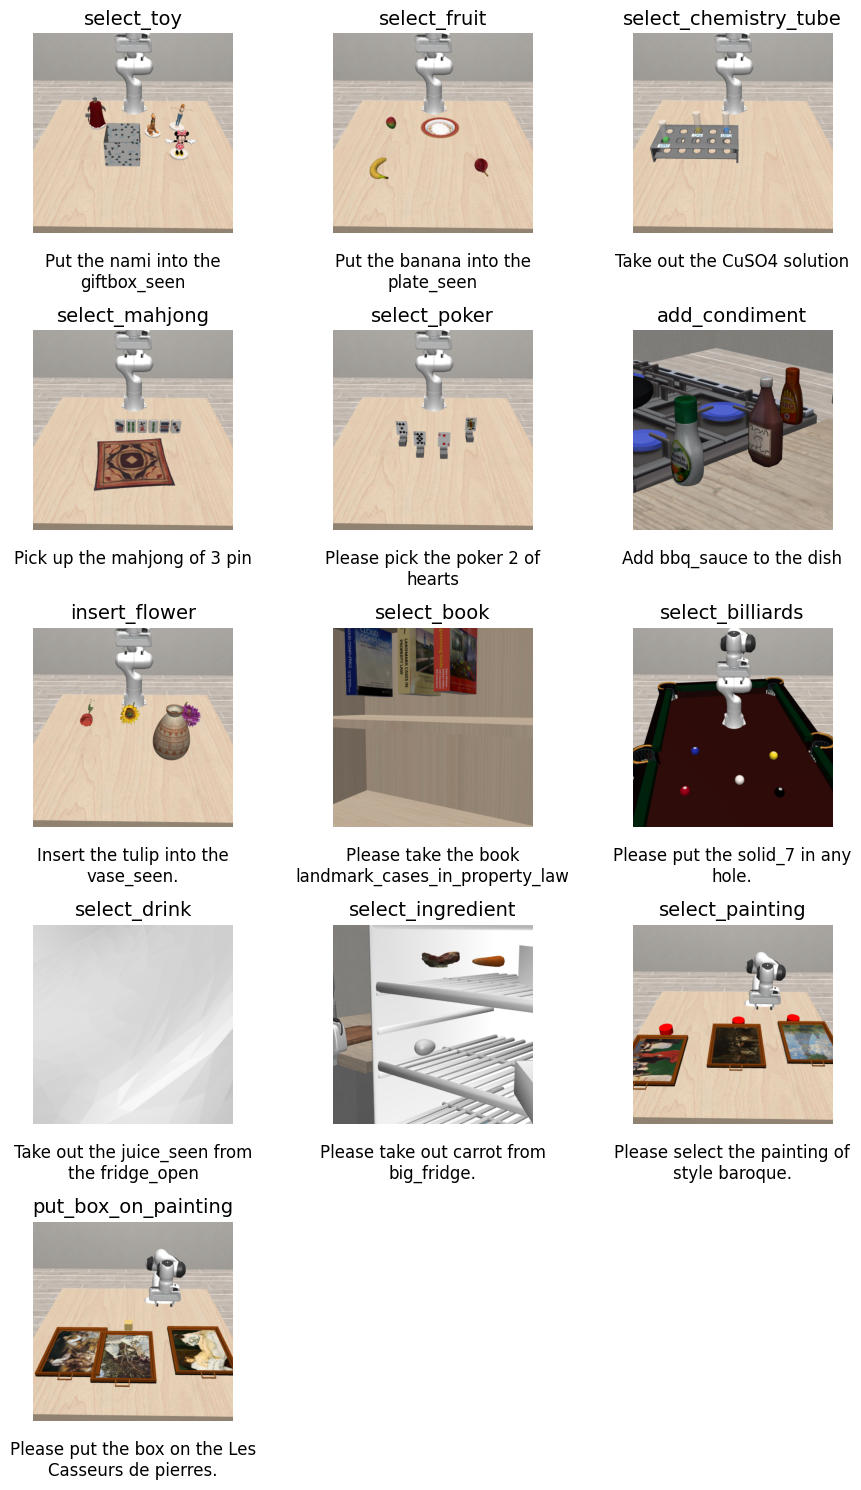

In [7]:
tasks_to_load = ["select_toy", "select_fruit", "select_chemistry_tube", "select_mahjong", "select_poker", "add_condiment", "insert_flower", "select_book", "select_billiards", "select_drink", "select_ingredient", "select_painting","put_box_on_painting"]
images, instructions = [], []
for task in tasks_to_load:
    try:
        image, instruction = load_env_and_render(task, robot, reset_wait_step=0)
        images.append(image)
        instructions.append(instruction)
    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"Failed to load task {task}: {e}")
plot_images(images, instructions, titles=tasks_to_load, max_columns=3)


### 2.2 Common Sense & World Knowledge

The base environment for Common Sense & World Knowledge type tasks quering LLM to generate task instructions by default. We also recommend to generate the instructions in batch later.

In [8]:
tasks_to_load = ["hammer_loose_nail"]

### 2.3 Spatial Understanding

The base environment for spatial understanding generate the relative spatial relationships between target entity and other entities by task-specific rules.

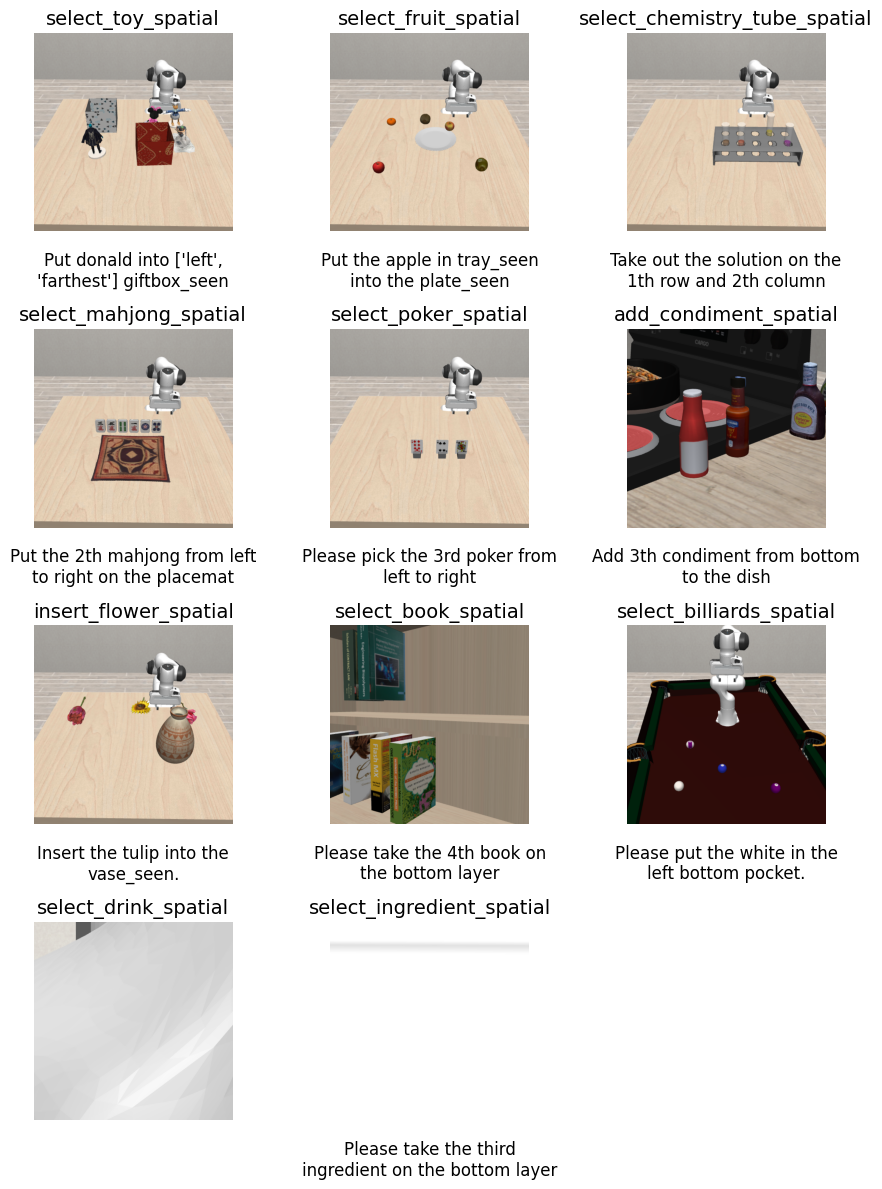

In [9]:
tasks_to_load = ["select_toy_spatial", "select_fruit_spatial", "select_chemistry_tube_spatial", "select_mahjong_spatial", "select_poker_spatial", "add_condiment_spatial", "insert_flower_spatial", "select_book_spatial", "select_billiards_spatial", "select_drink_spatial", "select_ingredient_spatial"]
# "", "select_poker", "add_condiment", "insert_flower", "select_book", "select_billiards", "select_drink", "select_ingredient", "select_painting","put_box_on_painting"
images, instructions = [], []
robot="franka"
for task in tasks_to_load:
    try:
        image, instruction = load_env_and_render(task, robot, reset_wait_step=0)
        images.append(image)
        instructions.append(instruction)
    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"Failed to load task {task}: {e}")
plot_images(images, instructions, titles=tasks_to_load, max_columns=3)

### 2.4 Semantic Understanding

In [13]:
tasks_to_load = ["select_toy_semantic", "select_fruit_semantic"]
for task in tasks_to_load:
    try:
        image, instruction = load_env_and_render(task, robot, reset_wait_step=0)
        images.append(image)
        instructions.append(instruction)
    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"Failed to load task {task}: {e}")


In [14]:
instructions

["It's a conversation",
 "tell some specifics of apple between ['apple', 'lemon', 'mango', 'pear']"]

## 3.Overview of Composite Tasks

### 3.1Cluster series tasks

In [ ]:
tasks_to_load = ["cluster_book", "cluster_billiards", "cluster_toy", "cluster_dessert", "cluster_drink", "cluster_ingredients"]
images, instructions = [], []
# for task in tasks_to_load:
#     image, instruction = load_env_and_render(task, robot, reset_wait_step=0)
#     images.append(image)
#     instructions.append(instruction)
robot="franka"
for task in tasks_to_load:
    try:
        image, instruction = load_env_and_render(task, robot, reset_wait_step=0)
        images.append(image)
        instructions.append(instruction)
    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"Failed to load task {task}: {e}")
plot_images(images, instructions, titles=tasks_to_load, max_columns=3)

### 3.2 Other Composite Tasks 

In [ ]:
tasks_to_load = ["texas_holdem", "texas_holdem_explore", "set_dining_table", "set_dining_left_hand", "set_dining_chopstick", "find_unseen_object", "cool_drink", "take_out_cool_drink", "book_rearrange", "heat_food", "rearrange_tube", "take_chemistry_experiment", "get_coffee", "get_coffee_with_sugar", "get_coffee_with_milk", "hammer_nail_and_hang_picture", "make_juice", "cook_dishes", "store_food", "play_mahjong", "complex_seesaw_use", "play_math_game", "set_study_table"]
images, instructions = [], []
# for task in tasks_to_load:
#     image, instruction = load_env_and_render(task, robot, reset_wait_step=0)
#     images.append(image)
#     instructions.append(instruction)
robot="franka"
for task in tasks_to_load:
    try:
        image, instruction = load_env_and_render(task, robot, reset_wait_step=0)
        images.append(image)
        instructions.append(instruction)
    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"Failed to load task {task}: {e}")

plot_images(images, instructions, titles=tasks_to_load, max_columns=3)